In [153]:
import scipy
from pathlib import Path
import numpy as np
import pandas as pd
import trimesh
from pathlib import Path
from dataclasses import dataclass
import numpy as np

In [17]:
DATASET_ROOT = Path("dropbox")
SUBFOLDERS = [
    "boxes", "labels", "models", "obbs", "ops", "part mesh indices", "syms"
]

rows = []

for category_path in DATASET_ROOT.iterdir():
    if not category_path.is_dir():
        continue
    category_name = category_path.name
    syms_folder = category_path / "syms"
    if not syms_folder.exists():
        continue

    for mat_file in syms_folder.glob("*.mat"):
        data = scipy.io.loadmat(mat_file)
        if "shapename" not in data:
            continue
        shape_name = str(data["shapename"].squeeze())
        row_name = f"{category_name}_{mat_file.stem}"
        row = {"shape": row_name}

        for sub in SUBFOLDERS:
            sub_path = category_path / sub
            if sub_path.exists():
                if sub == "models":
                    obj_file = sub_path / f"{shape_name}.obj"
                    row[sub] = str(obj_file) if obj_file.exists() else None
                elif sub == "obbs":
                    obb_file = sub_path / f"{shape_name}.obb"
                    row[sub] = str(obb_file) if obb_file.exists() else None
                else:
                    candidate = sub_path / mat_file.name
                    row[sub] = str(candidate) if candidate.exists() else None
            else:
                row[sub] = None

        rows.append(row)

df = pd.DataFrame(rows).set_index("shape").sort_index()
df.columns = [c.replace(" ", "_") for c in df.columns]
df.to_csv("dataset_overview.csv")
print("Saved to 'dataset_overview.csv'")

Saved to 'dataset_overview.csv'


In [208]:
# Load CSV and get Chair_1 row
df = pd.read_csv("dataset_overview.csv", index_col="shape")
chair_row = df.loc["Chair_40"]

In [209]:
@dataclass
class ShapeData:
    boxes: np.ndarray = None
    labels: np.ndarray = None
    models: str = None
    obbs: str = None
    ops: np.ndarray = None
    part_mesh_indices: np.ndarray = None
    syms: np.ndarray = None
    shapename: str = None

    def __init__(self, row):
        """
        Initialize ShapeData from a DataFrame row like chair_1_row.
        `row` should contain columns: boxes, labels, models, obbs, ops,
        part mesh indices, syms
        """
        # Load .mat files as numpy arrays
        if row.boxes:       self.boxes = scipy.io.loadmat(row.boxes).get("box", None)
        if row.labels:      self.labels = scipy.io.loadmat(row.labels).get("label", None)
        if row.ops:         self.ops = scipy.io.loadmat(row.ops).get("op", None)
        if row.part_mesh_indices:
            self.part_mesh_indices = scipy.io.loadmat(row.part_mesh_indices).get("cell_boxs_correspond_objSerialNumber", None)
        if row.syms:
            sym_mat = scipy.io.loadmat(row.syms)
            self.syms = sym_mat.get("sym", None)
            self.shapename = str(sym_mat.get("shapename", None).squeeze())

        # Store paths to .obj and .obb
        self.models = row.models if row.models else None
        self.obbs = row.obbs if row.obbs else None

In [210]:
def display_section(description, data):
    print(f"\n=== {description} ===")
    if isinstance(data, (list, tuple, np.ndarray)):
        print(data)
    else:
        print(f"  {data}")

# Mapping folder names to human-readable descriptions
file_descriptions = {
    "boxes": "Part bounding boxes for leaf nodes",
    "labels": "Semantic labels for each leaf node",
    "models": "3D mesh model (.obj)",
    "obbs": "Oriented bounding boxes for the whole shape",
    "ops": "Node types of the symmetry hierarchy (0=leaf,1=adjacency,2=symmetry)",
    "part mesh indices": "Part mesh indices for leaf nodes",
    "syms": "Symmetry parameters for each symmetry node"
}

# Assuming chair_1_row is a row from your CSV
chair = ShapeData(chair_row)

display_section(file_descriptions["boxes"], chair.boxes)
display_section(file_descriptions["labels"], chair.labels)
display_section(file_descriptions["models"], chair.models)
display_section(file_descriptions["obbs"], chair.obbs)
display_section(file_descriptions["ops"], chair.ops)
display_section(file_descriptions["part mesh indices"], chair.part_mesh_indices)
display_section(file_descriptions["syms"], chair.syms)
display_section("Shape name", chair.shapename)


=== Part bounding boxes for leaf nodes ===
[[-1.36019e-03 -3.77302e-01 -3.77302e-01 -9.52000e-04 -9.52000e-04
  -3.77696e-01]
 [-6.48673e-02 -4.63641e-01 -4.84842e-01  5.81306e-01  7.01906e-01
   2.81257e-01]
 [ 9.43229e-02  4.92089e-01 -3.09025e-01 -3.19634e-01 -3.61564e-01
  -2.94744e-01]
 [ 2.12621e-01  6.89583e-01  6.47180e-01  5.31350e-02  6.44293e-02
   9.27392e-01]
 [ 8.61949e-01  6.62490e-02  1.15674e-01  7.32670e-02  7.90324e-02
   1.30305e-01]
 [ 8.05898e-01  5.25220e-02  5.25220e-02  7.02876e-01  7.02876e-01
   5.76275e-02]
 [-8.31326e-03  0.00000e+00  0.00000e+00  0.00000e+00 -3.04888e-09
  -1.88761e-03]
 [ 9.97931e-01  1.00000e+00  1.00000e+00  1.00000e+00  8.68380e-01
   9.97792e-01]
 [-6.37486e-02  0.00000e+00  0.00000e+00  0.00000e+00 -4.95900e-01
  -6.63891e-02]
 [-2.65254e-04  0.00000e+00  0.00000e+00  0.00000e+00 -5.25211e-09
  -3.86040e-02]
 [ 6.37486e-02  0.00000e+00  0.00000e+00  0.00000e+00  4.95900e-01
   6.62670e-02]
 [ 9.97966e-01  1.00000e+00  1.00000e+00  1

In [211]:
# Load the mesh
# mesh = trimesh.load(chair.models, force='mesh')
# Quick info
# print(mesh)  # Shows number of vertices, faces, etc.
# Visualize in a window
# mesh.show()

In [212]:
from enum import Enum


class Tree(object):
    class NodeType(Enum):
        BOX = 0  # box node
        ADJ = 1  # adjacency (adjacent part assembly) node
        SYM = 2  # symmetry (symmetric part grouping) node

    class Node(object):
        def __init__(self, box=None, left=None, right=None, node_type=None, sym=None, label=None):
            self.box = box          # box feature vector for a leaf node
            self.sym = sym          # symmetry parameter vector for a symmetry node
            self.left = left        # left child for ADJ or SYM (a symmeter generator)
            self.right = right      # right child
            self.node_type = node_type
            self.label = label

        def is_leaf(self):
            return self.node_type == Tree.NodeType.BOX and self.box is not None

        def is_adj(self):
            return self.node_type == Tree.NodeType.ADJ

        def is_sym(self):
            return self.node_type == Tree.NodeType.SYM

    def __init__(self, boxes, ops, syms, labels):
        box_list = [b for b in torch.split(boxes, 1, 0)]
        sym_param = [s for s in torch.split(syms, 1, 0)]
        label_list = [l for l in labels[0]]
        box_list.reverse()
        sym_param.reverse()
        label_list.reverse()
        queue = []
        for id in range(ops.size()[1]):
            if ops[0, id] == Tree.NodeType.BOX.value:
                queue.append(Tree.Node(box=box_list.pop(), node_type=Tree.NodeType.BOX, label=label_list.pop()))
            elif ops[0, id] == Tree.NodeType.ADJ.value:
                left_node = queue.pop()
                right_node = queue.pop()
                queue.append(Tree.Node(left=left_node, right=right_node, node_type=Tree.NodeType.ADJ))
            elif ops[0, id] == Tree.NodeType.SYM.value:
                node = queue.pop()
                queue.append(Tree.Node(left=node, sym=sym_param.pop(), node_type=Tree.NodeType.SYM))
        assert len(queue) == 1
        self.root = queue[0]

In [213]:
import torch

# Assuming these are numpy arrays from your display
boxes = torch.tensor(chair.boxes, dtype=torch.float).t()  # transpose like the GRASSDataset does
ops = torch.tensor(chair.ops, dtype=torch.int)
syms = torch.tensor(chair.syms, dtype=torch.float).t()    # transpose like GRASSDataset
labels = torch.tensor(chair.labels, dtype=torch.int)

# Build the tree
tree = Tree(boxes, ops, syms, labels)

In [214]:
# Map numeric labels to human-readable part names
label_names = {
    0: "Backrest",
    1: "Seat",
    2: "Leg",
    3: "Armrest"
}

def print_full_tree(node, prefix="", is_last=True):
    """
    Print a fully annotated tree with all parameters:
    - Leaf nodes: label, name, bounding box
    - Symmetry nodes: parameters
    - ADJ nodes: just indicate type
    """
    branch = "└─ " if is_last else "├─ "

    if node.is_leaf():
        part_name = label_names.get(node.label.item(), f"Unknown({node.label.item()})")
        box_values = node.box.squeeze().tolist()
        print(f"{prefix}{branch}Leaf: {part_name}, Label={node.label.item()}, Box={box_values}")
    elif node.is_adj():
        print(f"{prefix}{branch}Adjacency Node")
        children = [node.left, node.right]
        for i, child in enumerate(children):
            print_full_tree(child, prefix + ("    " if is_last else "│   "), i == len(children)-1)
    elif node.is_sym():
        sym_values = node.sym.squeeze().tolist()
        print(f"{prefix}{branch}Symmetry Node: Sym Params={sym_values}")
        print_full_tree(node.left, prefix + ("    " if is_last else "│   "), True)
    else:
        print(f"{prefix}{branch}Unknown Node Type")

# Print the full tree for your chair
print("Fully Annotated Chair Tree:")
print_full_tree(tree.root)

Fully Annotated Chair Tree:
└─ Adjacency Node
    ├─ Adjacency Node
    │   ├─ Adjacency Node
    │   │   ├─ Symmetry Node: Sym Params=[0.0, 0.9980499744415283, 0.062380701303482056, -0.002196539891883731, -0.0011186300544068217, 0.3047940135002136, -0.29557299613952637, 0.0]
    │   │   │   └─ Leaf: Backrest, Label=0, Box=[-0.3776960074901581, 0.2812570035457611, -0.29474401473999023, 0.9273920059204102, 0.13030500710010529, 0.05762749910354614, -0.001887609949335456, 0.9977920055389404, -0.06638909876346588, -0.038603998720645905, 0.0662669986486435, 0.9970549941062927]
    │   │   └─ Leaf: Backrest, Label=0, Box=[-0.0009519999730400741, 0.7019060254096985, -0.3615640103816986, 0.06442929804325104, 0.07903239876031876, 0.7028759717941284, -3.0488800373262848e-09, 0.8683800101280212, -0.4959000051021576, -5.2521098581337355e-09, 0.4959000051021576, 0.8683800101280212]
    │   └─ Symmetry Node: Sym Params=[1.0, -0.00047599998652003706, 0.40201300382614136, -0.18330949544906616, -0.0009

In [215]:
from __future__ import print_function, division
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg as LA
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

def parse_obb_file(obb_path):
    """
    Parse an .obb file and return structured data.
    """
    data = {'boxes': [], 'connections': [], 'symmetries': [], 'labels': []}
    
    try:
        with open(obb_path, 'r') as f:
            content = f.read()
        lines = content.strip().split('\n')
    except:
        print(f"Error reading file: {obb_path}")
        return None
    
    current_section = None
    current_symmetry_group = None
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Check for section headers
        if line.startswith('N '):
            current_section = 'boxes'
            continue
        elif line.startswith('C '):
            current_section = 'connections'
            continue
        elif line.startswith('S '):
            current_section = 'symmetries'
            continue
        elif line.startswith('L '):
            current_section = 'labels'
            continue
        
        # Parse content
        if current_section == 'boxes':
            parts = list(map(float, line.split()))
            if len(parts) == 15:
                box = {
                    'position': np.array(parts[0:3]),
                    'rotation': np.array(parts[3:12]).reshape(3, 3),
                    'dimensions': np.array(parts[12:15])
                }
                data['boxes'].append(box)
        
        elif current_section == 'connections':
            parts = line.split()
            if len(parts) == 2:
                data['connections'].append((int(parts[0]), int(parts[1])))
        
        elif current_section == 'symmetries':
            parts = line.split()
            if len(parts) == 1 and parts[0].isdigit():
                current_symmetry_group = {'num_boxes': int(parts[0]), 'boxes': [], 'parameters': []}
                data['symmetries'].append(current_symmetry_group)
            elif current_symmetry_group:
                if parts[0].isdigit():
                    current_symmetry_group['boxes'].append({
                        'index': int(parts[0]),
                        'position': np.array(list(map(float, parts[1:4])))
                    })
                else:
                    params = []
                    for part in parts:
                        try:
                            params.append(float(part))
                        except:
                            params.append(part)
                    current_symmetry_group['parameters'].append(params)
        
        elif current_section == 'labels':
            if line.isdigit() or (line[0] == '-' and line[1:].isdigit()):
                data['labels'].append(int(line))
    
    return data

def draw_obb(ax, box_data, color='blue', alpha=0.6):
    """Draw a single oriented bounding box."""
    center = box_data['position']
    lengths = box_data['dimensions']
    rotation = box_data['rotation']
    
    # Get the three orthogonal directions from rotation matrix
    dir1 = rotation[:, 0]
    dir2 = rotation[:, 1]
    dir3 = np.cross(dir1, dir2)
    
    # Normalize directions
    dir1 = dir1 / LA.norm(dir1)
    dir2 = dir2 / LA.norm(dir2)
    dir3 = dir3 / LA.norm(dir3)
    
    # Compute corner points
    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3
    
    corners = np.array([
        center - d1 - d2 - d3,  # 0
        center - d1 + d2 - d3,  # 1
        center + d1 - d2 - d3,  # 2
        center + d1 + d2 - d3,  # 3
        center - d1 - d2 + d3,  # 4
        center - d1 + d2 + d3,  # 5
        center + d1 - d2 + d3,  # 6
        center + d1 + d2 + d3   # 7
    ])
    
    # Define edges
    edges = [
        (0,1), (0,2), (1,3), (2,3),  # bottom
        (4,5), (4,6), (5,7), (6,7),  # top
        (0,4), (1,5), (2,6), (3,7)   # sides
    ]
    
    # Draw edges
    for edge in edges:
        i, j = edge
        ax.plot([corners[i,0], corners[j,0]], 
                [corners[i,1], corners[j,1]], 
                [corners[i,2], corners[j,2]], 
                color=color, linewidth=2)
    
    # Draw transparent faces
    from matplotlib.colors import to_rgba
    face_color = to_rgba(color, alpha=alpha*0.3)
    
    # Bottom face
    bottom_verts = [corners[0], corners[1], corners[3], corners[2]]
    bottom_poly = plt.Polygon([(v[0], v[1]) for v in bottom_verts], color=face_color)
    ax.add_patch(bottom_poly)
    art3d.pathpatch_2d_to_3d(bottom_poly, z=corners[0,2], zdir="z")
    
    # Top face
    top_verts = [corners[4], corners[5], corners[7], corners[6]]
    top_poly = plt.Polygon([(v[0], v[1]) for v in top_verts], color=face_color)
    ax.add_patch(top_poly)
    art3d.pathpatch_2d_to_3d(top_poly, z=corners[4,2], zdir="z")

def visualize_parsed_obbs(parsed_data, title="Chair OBB Visualization"):
    """Visualize all OBBs from parsed data."""
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Color mapping for different part types
    color_map = {0: 'red', 1: 'green', 2: 'blue'}  # Backrest, Seat, Leg
    label_names = {0: 'Backrest', 1: 'Seat', 2: 'Leg'}
    
    # Draw each OBB with appropriate color
    for i, box in enumerate(parsed_data['boxes']):
        if i < len(parsed_data['labels']):
            label = parsed_data['labels'][i]
            color = color_map.get(label, 'gray')
            part_name = label_names.get(label, 'Unknown')
        else:
            color = 'gray'
            part_name = 'Unknown'
        
        draw_obb(ax, box, color=color)
        
        # Add label text
        ax.text(box['position'][0], box['position'][1], box['position'][2], 
                f'Box {i}\n({part_name})', fontsize=8, ha='center')
    
    # Draw connections
    for src, dst in parsed_data['connections']:
        if src < len(parsed_data['boxes']) and dst < len(parsed_data['boxes']):
            pos1 = parsed_data['boxes'][src]['position']
            pos2 = parsed_data['boxes'][dst]['position']
            ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], [pos1[2], pos2[2]], 
                   'k--', linewidth=1, alpha=0.5)
    
    # Set axis properties
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # Set equal aspect ratio
    all_positions = np.array([box['position'] for box in parsed_data['boxes']])
    max_range = np.max(np.ptp(all_positions, axis=0)) * 1.2
    mid_x, mid_y, mid_z = np.mean(all_positions, axis=0)
    
    ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
    ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[i], label=label_names[i]) 
                      for i in color_map]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

def print_parsed_info(parsed_data):
    """Print information about the parsed OBB data."""
    print("=== PARSED OBB INFORMATION ===")
    print(f"Total boxes: {len(parsed_data['boxes'])}")
    print(f"Total connections: {len(parsed_data['connections'])}")
    print(f"Total symmetry groups: {len(parsed_data['symmetries'])}")
    print(f"Total labels: {len(parsed_data['labels'])}")
    
    print("\n--- Box Details ---")
    label_names = {0: 'Backrest', 1: 'Seat', 2: 'Leg'}
    for i, box in enumerate(parsed_data['boxes']):
        label = parsed_data['labels'][i] if i < len(parsed_data['labels']) else -1
        part_name = label_names.get(label, 'Unknown')
        print(f"Box {i}: {part_name} at {box['position']}, size {box['dimensions']}")
    
    print("\n--- Connections ---")
    for i, (src, dst) in enumerate(parsed_data['connections']):
        print(f"Connection {i}: Box {src} ↔ Box {dst}")
    
    print("\n--- Symmetry Groups ---")
    for i, group in enumerate(parsed_data['symmetries']):
        print(f"Group {i}: {group['num_boxes']} boxes")
        for box_info in group['boxes']:
            print(f"  Box {box_info['index']} at {box_info['position']}")

=== PARSED OBB INFORMATION ===
Total boxes: 11
Total connections: 21
Total symmetry groups: 8
Total labels: 11

--- Box Details ---
Box 0: Backrest at [-0.000952  0.701906 -0.361564], size [0.0644293 0.0790324 0.702876 ]
Box 1: Leg at [ 0.375398 -0.463644  0.493652], size [0.052522 0.689576 0.063123]
Box 2: Leg at [ 0.375398 -0.483013 -0.309025], size [0.052522 0.650839 0.115674]
Box 3: Leg at [-0.377302 -0.484842 -0.309025], size [0.052522 0.64718  0.115674]
Box 4: Leg at [-0.377302 -0.463641  0.492089], size [0.052522 0.689583 0.066249]
Box 5: Seat at [-0.00136019 -0.0648673   0.0943229 ], size [0.805898 0.212621 0.861949]
Box 6: Backrest at [ 0.375459  0.328331 -0.296402], size [0.124143 0.053483 0.83576 ]
Box 7: Backrest at [-0.377696  0.281257 -0.294744], size [0.130305  0.0576275 0.927392 ]
Box 8: Backrest at [-0.000952  0.358586 -0.272649], size [0.702876 0.047104 0.070827]
Box 9: Backrest at [-0.000952  0.472897 -0.292347], size [0.702876 0.049645 0.071926]
Box 10: Backrest at 

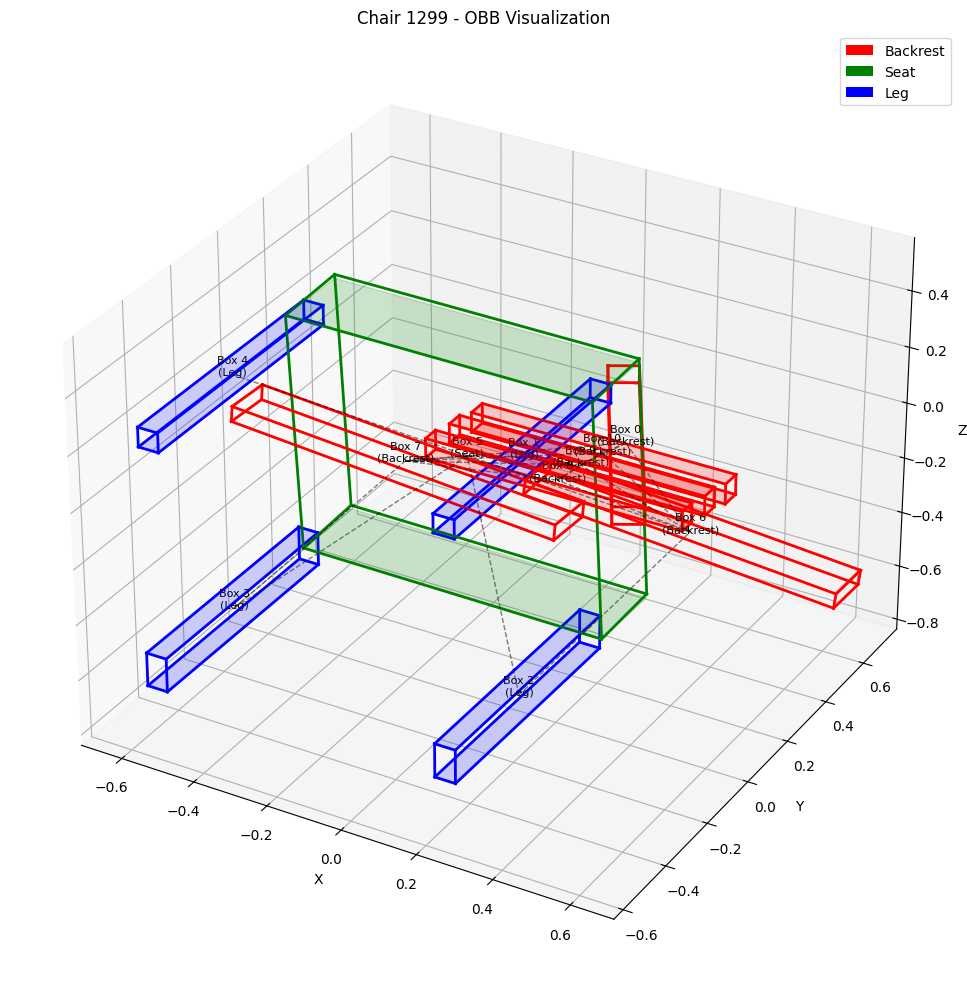

Visualization complete! Close the plot window to exit.


In [216]:
# Parse the OBB file
parsed_data = parse_obb_file(chair.obbs)

if parsed_data:
    # Print information
    print_parsed_info(parsed_data)
    
    # Visualize in 3D
    print("\nGenerating 3D visualization...")
    import matplotlib.patches as mpatches
    from mpl_toolkits.mplot3d import art3d
    
    fig, ax = visualize_parsed_obbs(parsed_data, "Chair 1299 - OBB Visualization")
    
    print("Visualization complete! Close the plot window to exit.")
else:
    print("Failed to parse OBB file.")

In [217]:
mesh = trimesh.load(chair.models, force='mesh')
# Quick info
# print(mesh)  # Shows number of vertices, faces, etc.
# Visualize in a window
mesh.show()

In [218]:
def print_obb_file(file_path):
    """
    Print the entire contents of a .obb file.
    """
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        print(content)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print_obb_file(chair.obbs)

N 11
-0.000952 0.701906 -0.361564 -3.04888e-09 0.86838 -0.4959 -5.25211e-09 0.4959 0.86838 1 5.25211e-09 3.04888e-09 0.0644293 0.0790324 0.702876
0.375398 -0.463644 0.493652 1 0 0 0 1 0 0 0 1 0.052522 0.689576 0.063123
0.375398 -0.483013 -0.309025 1 0 0 0 1 0 0 0 1 0.052522 0.650839 0.115674
-0.377302 -0.484842 -0.309025 1 0 0 0 1 0 0 0 1 0.052522 0.64718 0.115674
-0.377302 -0.463641 0.492089 1 0 0 0 1 0 0 0 1 0.052522 0.689583 0.066249
-0.00136019 -0.0648673 0.0943229 0.999965 0.00831326 -0.000265254 -0.00831326 0.997931 -0.0637486 -0.000265254 0.0637486 0.997966 0.805898 0.212621 0.861949
0.375459 0.328331 -0.296402 0.0111363 -0.093475 -0.995559 0.999938 0.0008241 0.0111079 -0.000217867 -0.995621 0.0934783 0.124143 0.053483 0.83576
-0.377696 0.281257 -0.294744 0.038604 -0.066267 -0.997055 0.999253 0.00444493 0.0383937 0.00188761 -0.997792 0.0663891 0.130305 0.0576275 0.927392
-0.000952 0.358586 -0.272649 1 0 0 0 1 0 0 0 1 0.702876 0.047104 0.070827
-0.000952 0.472897 -0.292347 1 0 0 